<a href="https://colab.research.google.com/github/Foyceek/MLF_2026_HECL_Frantisek/blob/main/Ex_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU, Flatten
from keras.preprocessing.sequence import pad_sequences
# from keras.preprocessing.text import Tokenizer


### 1.1 Generating dataset

In [ ]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [ ]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [ ]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [ ]:
no_training_epochs = 5

### 1.3 Data examination

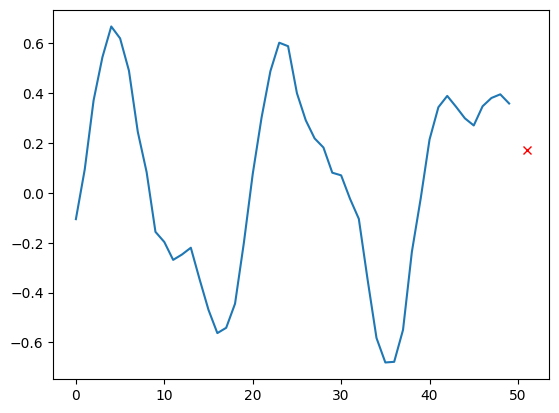

In [ ]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [ ]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [ ]:
model_linear.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1524 - mean_squared_error: 0.1524 - val_loss: 0.0428 - val_mean_squared_error: 0.0428
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0285 - mean_squared_error: 0.0285 - val_loss: 0.0177 - val_mean_squared_error: 0.0177
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0145 - mean_squared_error: 0.0145 - val_loss: 0.0113 - val_mean_squared_error: 0.0113
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0093 - val_mean_squared_error: 0.0093
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0082 - val_mean_squared_error: 0.0082


In [ ]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

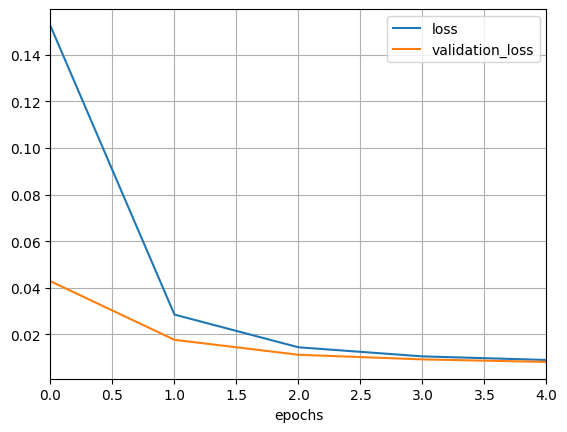

In [ ]:
plot_function(history_linear)

In [ ]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.008198373951017857
Test MSE:  0.008198373951017857


### 1.5 Simple RNN Model

In [ ]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [ ]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2976 - mean_squared_error: 0.2976 - val_loss: 0.2453 - val_mean_squared_error: 0.2453
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1801 - mean_squared_error: 0.1801 - val_loss: 0.1314 - val_mean_squared_error: 0.1314
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0878 - mean_squared_error: 0.0878 - val_loss: 0.0619 - val_mean_squared_error: 0.0619
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0461 - mean_squared_error: 0.0461 - val_loss: 0.0384 - val_mean_squared_error: 0.0384
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0342 - mean_squared_error: 0.0342 - val_loss: 0.0321 - val_mean_squared_error: 0.0321


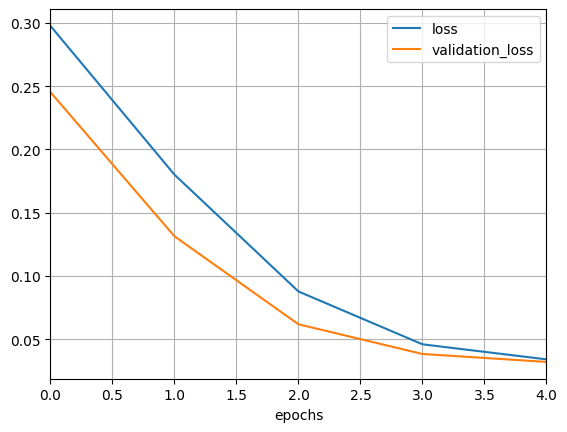

In [ ]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [ ]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [ ]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [ ]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0240 - mean_squared_error: 0.0240 - val_loss: 0.0054 - val_mean_squared_error: 0.0054
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0039 - val_mean_squared_error: 0.0039
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0031 - val_mean_squared_error: 0.0031
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0032 - val_mean_squared_error: 0.0032
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0029 - mean_squared_error: 0.0029 - val_loss: 0.0030 - val_mean_squared_error: 0.0030


In [ ]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0031595949549227953
Test MSE:  0.0031595949549227953


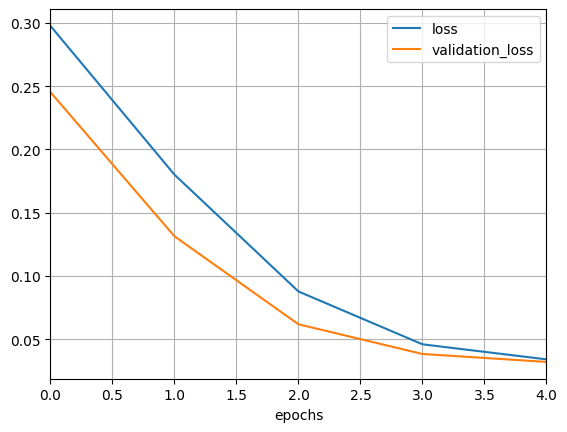

In [ ]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

### 2.1 - Load dataset

In [ ]:
size = 100000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words = size)

### 2.2 - Dataset examination

In [ ]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [ ]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [ ]:
single_sequence

"<sos> this film was just brilliant casting <unk> <unk> story direction <unk> really <unk> the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same <unk> <unk> as myself so i loved the fact there was a real <unk> with this film the <unk> <unk> throughout the film were great it was just brilliant so much that i <unk> the film as soon as it was released for <unk> and would recommend it to everyone to watch and the <unk> <unk> was amazing really <unk> at the end it was so sad and you know what they say if you <unk> at a film it must have been good and this definitely was also <unk> to the two little <unk> that played the <unk> of <unk> and paul they were just brilliant children are often left out of the <unk> <unk> i think because the stars that play them all <unk> up are such a big <unk> for the whole film but these children are amazing and should be <unk> for what they have done don't you

In [ ]:
# Iteration 1-2
# max_length = 150  # Define the maximum length of a review
# Iteration 3
max_length = 500
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [ ]:
# Iteration 1-2
embed_size = 128

# Iteration 1
# vocabulary_size = 1000

# Iteration 2
vocabulary_size = 10000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [ ]:
optimizer = Adam(learning_rate = 0.001)

In [ ]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [ ]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 83ms/step - accuracy: 0.4987 - loss: 0.7060 - val_accuracy: 0.5048 - val_loss: 0.6930
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 81ms/step - accuracy: 0.5042 - loss: 0.6962 - val_accuracy: 0.4938 - val_loss: 0.6944
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 84ms/step - accuracy: 0.4983 - loss: 0.6962 - val_accuracy: 0.5050 - val_loss: 0.6973
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.5020 - loss: 0.6950 - val_accuracy: 0.4950 - val_loss: 0.6933
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.5002 - loss: 0.6957 - val_accuracy: 0.5050 - val_loss: 0.7059


In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.7076490521430969
Test accuracy:  50.05199909210205 %


In [ ]:
#LSTM

# Iteration 1
# max_length = 150  # Define the maximum length of a review

# Iteration 2
max_length = 500

X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

embed_size = 128

# Iteration 1
# vocabulary_size = 1000

# Iteration 2
vocabulary_size = 10000

# Iteration 1
# model_lstm = keras.models.Sequential([
#     keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
#     keras.layers.LSTM(128, return_sequences=True),
#     keras.layers.LSTM(128),
#     keras.layers.Dense(1, activation='sigmoid')
# ])

# optimizer = Adam(learning_rate=0.001)

# model_lstm.compile(
#     loss="binary_crossentropy",
#     optimizer=optimizer,
#     metrics=["accuracy"]
# )

# history_lstm = model_lstm.fit(X_train, y_train, epochs=5, validation_split=0.2)

# Iteration 2
model_lstm = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, 128),
    keras.layers.Bidirectional(keras.layers.LSTM(128, return_sequences=True, dropout=0.2)),
    keras.layers.Bidirectional(keras.layers.LSTM(64, dropout=0.2)),
    keras.layers.Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)

model_lstm.compile(
    loss="binary_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

history_lstm = model_lstm.fit(X_train, y_train, epochs=10, batch_size = 32, validation_split=0.2)

score_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print("LSTM Test loss:", score_lstm[0])
print("LSTM Test accuracy:", score_lstm[1]*100, "%")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 79ms/step - accuracy: 0.6563 - loss: 0.6144 - val_accuracy: 0.7414 - val_loss: 0.5147
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.7589 - loss: 0.5038 - val_accuracy: 0.7824 - val_loss: 0.4892
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.8096 - loss: 0.4244 - val_accuracy: 0.8114 - val_loss: 0.4107
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.8302 - loss: 0.3828 - val_accuracy: 0.8242 - val_loss: 0.4004
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.8391 - loss: 0.3646 - val_accuracy: 0.8272 - val_loss: 0.3981
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.8510 - loss: 0.3480 - val_accuracy: 0.8280 - val_loss: 0.3820
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 77ms/step - accuracy: 0.8565 - loss: 0.3323 - val_accuracy: 0.8266 - val_loss: 0.3972
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.8619 - loss: 0.3185 - 

In [ ]:
# GRU

# Iteration 1
# max_length = 150  # Define the maximum length of a review

# Iteration 2
max_length = 300

X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

callbacks = [keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)]

# Iteration 1
# embed_size = 128

# Iteration 2
embed_size = 256

# Iteration 1
# vocabulary_size = 1000

# Iteration 2
vocabulary_size = 10000

# Iteration 1
# model_gru = keras.models.Sequential([
#     keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
#     keras.layers.GRU(128, return_sequences=True),
#     keras.layers.GRU(128),
#     keras.layers.Dense(1, activation='sigmoid')
# ])

# optimizer = Adam(learning_rate=0.001)

# model_gru.compile(
#     loss="binary_crossentropy",
#     optimizer=optimizer,
#     metrics=["accuracy"]
# )

# history_gru = model_gru.fit(X_train, y_train, epochs=5, validation_split=0.2)

# Iteration 2
model_gru = keras.models.Sequential([

    keras.layers.Embedding(vocabulary_size, embed_size),

    keras.layers.GRU(128, return_sequences=True),

    keras.layers.GlobalMaxPooling1D(),

    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dropout(0.1),

    keras.layers.Dense(1, activation="sigmoid")
])

optimizer = Adam(learning_rate=0.0003)

model_gru.compile(
    loss="binary_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks
)

score_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print("GRU Test loss:", score_gru[0])
print("GRU Test accuracy:", score_gru[1]*100, "%")

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6615 - loss: 0.6168 - val_accuracy: 0.8106 - val_loss: 0.4183
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8669 - loss: 0.3342 - val_accuracy: 0.8842 - val_loss: 0.2907
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9196 - loss: 0.2297 - val_accuracy: 0.8846 - val_loss: 0.2905
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9473 - loss: 0.1641 - val_accuracy: 0.8768 - val_loss: 0.3324
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9665 - loss: 0.1158 - val_accuracy: 0.8776 - val_loss: 0.3418
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9765 - loss: 0.0844 - val_accuracy: 0.8786 - val_loss: 0.3794
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9855 - loss: 0.0581 - val_accuracy: 0.8772 - val_loss: 0.4569
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9912 - loss: 0.0381 - val_accu

TASK: Modify structure, change the core of the network from RNN to LSTM and GRU. Compare the results.

# LSTM
Iteration 1 accuracy: 81.7 %

Iteration 2 (bidirectional) accuracy: 83.48 %

# GRU
Iteration 1 accuracy: 83.55 %

Iteration 2 accuracy: 87.28 %